<a href="https://colab.research.google.com/github/NoaTal1996/Backbone-Graph/blob/main/src/Topic_Clustring_and_NER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Instalations and Imports

In [ ]:
try:
    # Running inside Google Colab → use !pip
    import google.colab
    in_google_colab = True
    print("Running in Colab → installing packages...")
    !pip install -q bertopic
    !pip install -q tweet-preprocessor
    !pip install -q spacy-entity-linker
    !pip install -q emoji
    !pip install sentence-transformers scikit-learn
    !pip install "transformers>=4.40.0" sentencepiece accelerate torch
except ImportError:
    # Not running in Colab
    in_google_colab = False
    pass

In [ ]:
import pandas as pd
import pyarrow  # ensures pandas can read/write parquet
import matplotlib.pyplot as plt

import re
import emoji

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

import spacy

from tqdm.auto import tqdm
from IPython.display import display

# Loading and Exporting
[Labeled Datasets for Research on Information Operations](https://zenodo.org/records/14189193)

## Load Data

In [ ]:
dataset_name = "Labeled_Datasets/Ecuador"  # folder path
file_name = f"Ecuador_part_all.gzip.parquet"  # file name

# if run local: put data in "../data/<dataset_name>/<file_name>"
# Recommended: working directory is: "Backbone-Graph/src"

In [ ]:
from pathlib import Path

# Google Colab
if in_google_colab:
    from google.colab import drive
    drive.mount('/content/drive')
    dataset_path = Path("/content/drive/Shareddrives/KeyBoostAuthor") / dataset_name / file_name
    print("Running inside Colab. Loading from Google Drive...")

# Cluster\Local
else:
    # Recommended: working directory is: "Backbone-Graph/src"
    dataset_path = Path("../data") / dataset_name / file_name
    print(f"Running on local/cluster.\nLoading data from: {dataset_path}")


# Load the parquet file
df = pd.read_parquet(dataset_path)

# for testing
# df = df.sample(n=100, random_state=42).copy()

Running on local/cluster.
Loading data from: ../data/Labeled_Datasets/Ecuador/Ecuador_part_all.gzip.parquet


## Output Path


In [ ]:
from datetime import datetime
today = datetime.now().strftime("%Y_%m_%d")


dataset_path = Path(dataset_path)


if in_google_colab:
  output_folder_path = (dataset_path.parents[2] / "Labeled_Dataset_with_Topic_NER" / dataset_path.parent.name / dataset_path.name)
else:
  # working directory is: Backbone-Graph/src
  file_name_no_suffixes = file_name.split(".")[0]
  output_folder_path = Path("../results") / dataset_name / file_name_no_suffixes / today
  # Example: ""../results/Labeled_Datasets/Ecuador/Ecuador_part_4/2025_11_27"



output_folder_path.mkdir(parents=True, exist_ok=True) # Createst the output directory if needed

print(f"output_folder_path = {output_folder_path}")

output_folder_path = ../results/Labeled_Datasets/Ecuador/Ecuador_part_all/2025_12_21


In [ ]:
df.head()

,postid,post_text,application_name,post_language,in_reply_to_postid,in_reply_to_accountid,post_time,accountid,account_profile_description,follower_count,following_count,account_creation_date,is_repost,reposted_accountid,reposted_postid,hashtags,urls,account_mentions,is_control
769276,ca06f1aebbcaf871492fefb92090d0e2e3885dc5be,https://9b6e9a57746724dd79b953b2f0022721b53c58...,15592fcc82d5064a8f4a3b89774e6cd0bbd2118aa0,es,None,None,2018-06-06 23:58:11,b28a77b846f3964b7ef4a4134d662fb91726fb0f68,2 de octubre no se olvida. De sandía es mi cor...,659,629,2011-02-27,True,71a93e64fa7516b0e2a537a0f7a48c7bd6be6c5ac0,b5640970c915dcd5022a1612344b9a4d0bc986eefe,"[MeadeConLosJovenes, AvanzarConLosJovenes]",[https://9b6e9a57746724dd79b953b2f0022721b53c5...,"[71a93e64fa7516b0e2a537a0f7a48c7bd6be6c5ac0, 8...",True
860817,a90d3a1fd06ad7f5ad561d59d54c6602b653e77205,#VIDEO Chávez: Nuestro camino no es el odio ni...,62010408238d4a0f958ec97eec3db0a4f69bcd0d11,es,None,None,2018-08-05 23:48:18,b0afd37c06c5e6cfe04f6c50d5c6d3970a56db8a8b,"Joven Chavista y Revolucionario, Soñador de un...",2906,1088,2017-06-20,True,65652740c7b667c0721a0da49b1b1b9622f92debc3,9c665366e213e2395fc737ae93fd442538882edd61,[VIDEO],[https://486eba79e2b3d1f820cc0a91920ef1d2ba6c9...,"[65652740c7b667c0721a0da49b1b1b9622f92debc3, 2...",True
167907,fe6d263080973f8a0473f539bf970935b5d6b45e18,Infidelidad masculina luego del consumo de alc...,e3415c9cb59e8c2e081aab325f8e78eeef650d5b4b,es,None,None,2014-04-14 17:59:00,71cc57155d061d447c2c65756c7dfd6873e403a097,🍃🧚‍♀️🧜‍♀️👑,3618,2055,2009-12-22,False,None,None,[EsElColmo],[https://d7a745c4cdf26c5daf1d9379ac376329a5571...,[],False
395024,d3a1a0c4579b70c4bd1bb82dde38200ddaf5a953ef,Buenas tardes! Previo a la reinstalación de Au...,15592fcc82d5064a8f4a3b89774e6cd0bbd2118aa0,es,None,None,2017-02-28 21:56:48,2326bf7cce531ef18954c90de5b6df39f1cb263845,Delegación Provincial Electoral de Carchi ¡La ...,3852,154,2012-09-03,True,b23e5d244b7f7f67d27dbea12131fd6ddc078b33b0,84494d082eab2d0c2951414021df407efdbee2bbd0,[],[https://0258a6a9322da6f60c8ee98203fee669a7ddd...,"[b23e5d244b7f7f67d27dbea12131fd6ddc078b33b0, 8...",True
710506,c905d6b1b0eaa0d7f8ae2ebf2ca4f1594f5920d66c,#3bb1a651896e919384f4fd7c1a9464e09f8f41f6fa | ...,072f1b013621f1b0d9753c98d97f5a0a97a8b68303,es,None,None,2018-04-12 02:21:08,4326dbcdf4b8d52e4fa2104d60872b008082ea95a9,Periodista (Máster y otros) y trotamundos. Par...,14527,1014,2012-11-26,True,3bb1a651896e919384f4fd7c1a9464e09f8f41f6fa,63f107c0d79bbd255089e89f93e18f2667de2d9a49,"[TelediarioEC, CarlosBacaM]",[https://a574382865fc9d34ccb1613ae85e2f510fc89...,[3bb1a651896e919384f4fd7c1a9464e09f8f41f6fa],True


# Dataset Statistics

In [ ]:
total_posts = len(df)
hashtag_posts = df[df['hashtags'].notna() & (df['hashtags'].str.len() > 0)]
mention_posts = df[df['account_mentions'].notna() & (df['account_mentions'].str.len() > 0)]
url_posts = df[df['urls'].notna() & (df['urls'].str.len() > 0)]
start_date = df["post_time"].min().strftime("%Y-%m")
end_date = df["post_time"].max().strftime("%Y-%m")

stats_text = [
    f"Posts time range: {start_date} → {end_date}",
    "",
    f"{'df shape:':<40} {df.shape}",
    f"{'df posts with hashtags # shape:':<40} {hashtag_posts.shape}  ({len(hashtag_posts)/total_posts*100:.2f}%)",
    f"{'df posts with account_mentions @ shape:':<40} {mention_posts.shape}  ({len(mention_posts)/total_posts*100:.2f}%)",
    f"{'df posts with urls shape:':<40} {url_posts.shape}  ({len(url_posts)/total_posts*100:.2f}%)",
]

# print to console
print("\n".join(stats_text))

# save to file
if output_folder_path:
    output_folder_path = Path(output_folder_path)
    report_path = output_folder_path / "dataset_summary.txt"
    report_path.write_text("\n".join(stats_text), encoding="utf-8")

print()
print()

print(f"{'**collum name**':<30} **value type**")
for col in df.columns:
    # dtype_str = str(df[col].dtype)  # Convert dtype to string
    # get a sample non-null value if exists
    sample_val = df[col].dropna().iloc[0] if df[col].notna().any() else None
    print(f"{col:<30} | {type(sample_val).__name__}")


print()
print()
print(df['post_language'].value_counts())

Posts time range: 2011-09 → 2019-05

df shape:                                (100, 19)
df posts with hashtags # shape:          (42, 19)  (42.00%)
df posts with account_mentions @ shape:  (89, 19)  (89.00%)
df posts with urls shape:                (45, 19)  (45.00%)


**collum name**                **value type**
postid                         | str
post_text                      | str
application_name               | str
post_language                  | str
in_reply_to_postid             | str
in_reply_to_accountid          | str
post_time                      | Timestamp
accountid                      | str
account_profile_description    | str
follower_count                 | int64
following_count                | int64
account_creation_date          | date
is_repost                      | bool
reposted_accountid             | str
reposted_postid                | str
hashtags                       | ndarray
urls                           | ndarray
account_mentions               | nd

# Clean Text

## Clean text With Entities

In [ ]:
def clean_url(url_match):

    url = url_match.group(0)

    # 1. Remove protocol (http:// or https://)
    url = re.sub(r"https?://", "", url)
    url = re.sub(r"www\.", "", url)

    # 2. Remove query parameters (?x=1)
    url = url.split("?")[0]

    # 3. Split into components by "/"
    parts = url.split("/")

    # Domain (first part)
    domain = parts[0].replace(".", "_")  # twitter.com → twitter_com

    # First section (second part of the URL)
    if len(parts) > 1 and parts[1].strip() != "":
        section = parts[1].replace(".", "_")
        token = f" URL_{domain}_{section} "
    else:
        token = f" URL_{domain} "

    return token

In [ ]:
def clean_text(text: str) -> str:

    # lowercase
    text = str(text).lower()

    # URLs → domian + first section
    text = re.sub(r"(https?://\S+|www\.\S+)", clean_url, text)

    # Hashtags → HASHTAG_xxx
    text = re.sub(r"#(\w+)", r" HASHTAG_\1 ", text)

    # Mentions → MENTION_xxx
    text = re.sub(r"@(\w+)", r" MENTION_\1 ", text)

    # emoji → EMOJI_xxx
    text = emoji.demojize(text, delimiters=(" EMOJI_", " "))

    # Collapse spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [ ]:
df["clean_post_text_with_entities"] = df["post_text"].apply(clean_text)

## Remove Text Without Enttities

In [ ]:
import re
import pandas as pd

URL_RE = re.compile(r"(https?://\S+|www\.\S+)", flags=re.IGNORECASE)
MENTION_RE = re.compile(r"@\w+")
HASHTAG_RE = re.compile(r"#(\w+)")
WHITESPACE_RE = re.compile(r"\s+")

def clean_enteties(text: str) -> str:
    """
    Lightly clean a social-media post while keeping it natural
    for machine translation.

    Operations:
    - Replace URLs with <URL>
    - Replace @username with <USER>
    - Turn #hashtag into 'hashtag' (drop the #)
    - Collapse repeated whitespace
    """
    if not isinstance(text, str):
        text = str(text)

    # lowercase
    text = str(text).lower()

    # 1. Normalize URLs
    text = URL_RE.sub("<URL>", text)

    # 2. Normalize mentions
    text = MENTION_RE.sub("<USER>", text)

    # 3. Normalize hashtags: "#Ecuador2025" -> "Ecuador2025"
    text = HASHTAG_RE.sub(r"\1", text)

    # 4. Collapse whitespace
    text = WHITESPACE_RE.sub(" ", text).strip()

    return text

In [ ]:
df["clean_text_without_enteties"] = df["post_text"].astype(str).apply(clean_enteties)

In [ ]:
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 2000)

df[["post_text", "clean_text_without_enteties"]].sample(n=20)

,post_text,clean_text_no_enteties
1084740,@bef0e7981715abed0539a1eb8eedfdbf59651779f2 Que bueno que se estén tomando acciones para garantizar una educación inclusiva. #EcuadorEnLaCumbre #BuenVier…,<USER> que bueno que se estén tomando acciones para garantizar una educación inclusiva. ecuadorenlacumbre buenvier…
710506,"#3bb1a651896e919384f4fd7c1a9464e09f8f41f6fa | Fiscal #CarlosBacaM compareció ante la Comisión de Fiscalización de la Asamblea, dentro del proceso de juicio político en su contra. Cuestionó que se solicite a un juicio por hechos que no tienen vinculación con un presunto incumplimiento de sus funciones▼ https://a574382865fc9d34ccb1613ae85e2f510fc89b45c7","3bb1a651896e919384f4fd7c1a9464e09f8f41f6fa | fiscal carlosbacam compareció ante la comisión de fiscalización de la asamblea, dentro del proceso de juicio político en su contra. cuestionó que se solicite a un juicio por hechos que no tienen vinculación con un presunto incumplimiento de sus funciones▼ <URL>"
1059222,@bef0e7981715abed0539a1eb8eedfdbf59651779f2 el Gobierno Nacional trabaja también por nuestros hermanos amazónicos. La #AgendaGubernamental refleja…,<USER> el gobierno nacional trabaja también por nuestros hermanos amazónicos. la agendagubernamental refleja…
792050,"“La #LeyDeComunicación promueve el ejercicio de la libertad de expresión como un eje de la democracia, la misma que no…","“la leydecomunicación promueve el ejercicio de la libertad de expresión como un eje de la democracia, la misma que no…"
823786,".@99bfdc777e7b16cf6ae0524df534033e823f50257b y @e185769a4749bdabfa5db0eb24da11025541c097b0 firmó un acuerdo, para los estudios de factibilidad de la #UniversidadSantoDomingo, que in…",".<USER> y <USER> firmó un acuerdo, para los estudios de factibilidad de la universidadsantodomingo, que in…"
206794,Newbie : Tutorial Creating Responsive Slide-Toggle Menu with Jquery and CSS https://71b84f03d82e76f5be79b7c49dcb5b17ee18bf3eca #menu,newbie : tutorial creating responsive slide-toggle menu with jquery and css <URL> menu
605979,"En reuniones bilaterales con @08d931d0160470e822c035861dbfa8bb15322eee5b @3b8529ff2698452cc65dc57fe35380bb3833769aa2 y @013e16d6dfcb5b22d655f4ef0da77f04605f18dbde en @bebc6e11ab5139fd73a7278f28b641bc8979dad50e abordamos sobre el proceso político ecuatoriano, nuestro programa de gobierno y reformas al sistema de NNUU así como la candidatura propuesta de #Ecuador para @1e6f8471c09745f4c5672f1bbd4c1f57959514d536 https://daee4fb2e435eedca63498946804d82dde44106c8f","en reuniones bilaterales con <USER> <USER> y <USER> en <USER> abordamos sobre el proceso político ecuatoriano, nuestro programa de gobierno y reformas al sistema de nnuu así como la candidatura propuesta de ecuador para <USER> <URL>"
349560,@5a78e042823c211b1f9122c10cbb9c0b666a4feb44 @d8bcb6477dd0c48e06c5d1647384db10da14e09521 😊,<USER> <USER> 😊
189308,"""@bfed5edb5293d0a19ba70c8329294887fa263ac361: Propietarios exigen derecho al trabajo a la alcaldía de @ea659736e9cfcaaa784ba2c3671d476e26fd86adc4 https://ab5c3efd419154142791f1dbe8aee8d13d9d13de25"" @4f118f396497df4ad5c2d03c63949d7869b6f1eaf8 @703f0fb99d8387c39476f394648723263241dc27b3","""<USER>: propietarios exigen derecho al trabajo a la alcaldía de <USER> <URL> <USER> <USER>"
544268,"Por primera vez, la violencia machista ha pasado a ser cuestión de Estado. Buscad ayuda. #diacontralaviolenciadegenero https://60383d30672dcbafb8fdd82672513e89bb39ed23e6","por primera vez, la violencia machista ha pasado a ser cuestión de estado. buscad ayuda. diacontralaviolenciadegenero <URL>"


# Translation to English

In [ ]:
# map post_language codes to NLLB-200 language codes
# https://dl-translate.readthedocs.io/en/latest/available_languages/

def map_to_nllb_code(lang_code: str) -> str:
    """
    Map your dataset's post_language codes to NLLB-200 language codes.
    If not in mup return the same language code.
    Args:
        lang_code (str): Post language code.
    Returns:
        str: NLLB-200 language code.
    """
    nlln_mapping = {
    # Europe
    "en": "eng_Latn",   # English
    "es": "spa_Latn",   # Spanish
    "pt": "por_Latn",   # Portuguese
    "fr": "fra_Latn",   # French
    "de": "deu_Latn",   # German
    "it": "ita_Latn",   # Italian
    "nl": "nld_Latn",   # Dutch
    "ru": "rus_Cyrl",   # Russian
    "pl": "pol_Latn",   # Polish
    "sv": "swe_Latn",   # Swedish
    "ca": "cat_Latn",    # Catalan
    "cy": "cym_Latn",    # Welsh
    "et": "est_Latn",    # Estonian

    # Middle East
    "ar": "arb_Arab",   # Arabic (MSA)
    "he": "heb_Hebr",   # Hebrew
    "tr": "tur_Latn",   # Turkish
    "fa": "pes_Arab",   # Persian/Farsi

    # South Asia
    "hi": "hin_Deva",   # Hindi
    "ur": "urd_Arab",   # Urdu
    "bn": "ben_Beng",   # Bengali

    # East Asia
    "zh": "zho_Hans",   # Chinese Simplified
    "ja": "jpn_Jpan",   # Japanese
    "ko": "kor_Hang",   # Korean

    # Southeast Asia
    "vi": "vie_Latn",   # Vietnamese
    "id": "ind_Latn",   # Indonesian (modern code)
    "in": "ind_Latn",   # Indonesian (legacy ISO code)
    "tl": "tgl_Latn",   # Tagalog (Philippines)

    # Africa
    "sw": "swh_Latn",   # Swahili

    # Americas
    "qu": "quy_Latn",   # Quechua (Ayacucho)
}


    if lang_code in nlln_mapping:
        return nlln_mapping[lang_code]
    else:
        return lang_code

In [ ]:
df["post_language"] = df["post_language"].apply(map_to_nllb_code)

In [ ]:
# load models

import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline

MODEL_NAME = "facebook/nllb-200-distilled-600M"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(device)
translation_pipeline = pipeline("translation", model=model, tokenizer=tokenizer, device=device, max_length=1000, batch_size=16)

Using device: cuda


Device set to use cuda


In [ ]:
from tqdm.auto import tqdm


def transformers_translator(
    df: pd.DataFrame,
    translation_pipe,
    text_col: str = "clean_text_without_enteties",
    lang_col: str = "post_language",
    out_col: str = "translated_post",
    target_lang: str = "eng_Latn",
    pivot_lang: str = "spa_Latn",
    backtranslate_same_lang: bool = True,
) -> pd.DataFrame:
    """
    Translate df[text_col] → target_lang using NLLB pipeline.

    If src_lang == target_lang and backtranslate_same_lang=True,
    perform back-translation: target_lang → pivot_lang → target_lang.

    Args:
        df (pd.DataFrame):
            Input DataFrame containing text and language labels.
        translation_pipe (transformers.pipeline):
            Pre-loaded translation pipeline (e.g., NLLB-200).
        text_col (str):
            Column containing original text.
        lang_col (str):
            Column containing language codes matching the pipeline
            (e.g., "spa_Latn", "eng_Latn").
        out_col (str):
            Column name for the translated output.
        target_lang (str):
            Target language code (default: "eng_Latn").
        pivot_lang (str):
            Pivot language code for back-translation (default: "spa_Latn").
        backtranslate_same_lang (bool):
            If True, back-translate rows where src_lang == target_lang.

    Returns:
        pd.DataFrame:
            A DataFrame with the same index as df and one column (out_col).
    """

    result_df = pd.DataFrame(index=df.index)
    result_df[out_col] = None

    # Iterate per language with progress bar
    for src_lang, group in tqdm(df.groupby(lang_col), desc="Translating by language"):

        # Build a list[str]
        texts = group[text_col].astype(str).tolist()

        # Keep the original indexes so we can assign back later
        indexes = group.index.to_list()

        translated = []  # empty means "no translation done"

        # Case 1: normal translation src_lang -> target_lang
        if src_lang != target_lang:
            print(f"{len(texts)} posts: {src_lang} → {target_lang}")
            outputs = translation_pipe(
                texts,
                src_lang=src_lang,
                tgt_lang=target_lang,
            )
            translated = [o["translation_text"] for o in outputs]

        # Case 2: back-translation target_lang -> pivot_lang -> target_lang
        if (src_lang == target_lang) and backtranslate_same_lang:
            print(f"{len(texts)} posts: {target_lang} → {pivot_lang} → {target_lang}")
            pivot_outputs = translation_pipe(
                texts,
                src_lang=target_lang,
                tgt_lang=pivot_lang,
            )
            pivot_texts = [o["translation_text"] for o in pivot_outputs]

            back_outputs = translation_pipe(
                pivot_texts,
                src_lang=pivot_lang,
                tgt_lang=target_lang,
            )
            translated = [o["translation_text"] for o in back_outputs]

        if translated:
            result_df.loc[indexes, out_col] = translated

    return result_df

In [ ]:
print(f"df shape: {df.shape}")
translated_df = transformers_translator(df, translation_pipeline)
df = df.drop(columns=["translated_post"], errors="ignore") # Drop the old column if exist
df = df.join(translated_df)

df shape: (100, 21)


Translating by language:   0%|          | 0/7 [00:00<?, ?it/s]

1 posts: cat_Latn → eng_Latn
11 posts: eng_Latn → spa_Latn → eng_Latn
1 posts: ita_Latn → eng_Latn
1 posts: jpn_Jpan → eng_Latn
2 posts: por_Latn → eng_Latn
78 posts: spa_Latn → eng_Latn
5 posts: und → eng_Latn


In [ ]:
pd.set_option("display.width", 3000)
pd.set_option("display.max_colwidth", 1500)

df.sample(10)[["clean_text_without_enteties", "translated_post"]]

,clean_text_no_enteties,translated_post
687797,tiroteo en sede de youtube: cuatro personas resultaron heridas y una persona —la sospechosa del ataque— murió <URL> <URL>,YouTube shooting: Four people were injured and one person the suspect in the attack died <URL> <URL>
823786,".<USER> y <USER> firmó un acuerdo, para los estudios de factibilidad de la universidadsantodomingo, que in…",".<USER> and <USER> signed an agreement, for the feasibility studies of the university on Sunday, that in..."
1168934,a la justin parece que le hackearon el twitter,Justine looks like her twitter was hacked.
642533,gop majority on house intell cttee gave him air cover. gop in congress spineless. fox complicit. ag sessions was persuaded to unrecuse himself. independent-minded cohn &amp; tillerson gone. kelly &amp; mcgahn weak or worse. rapids and waterfall ahead. <URL>,GOP majority in the Intel Cttee House gave him air coverage. GOP in the Congress without a spine.
1102994,😋 <URL>,😋 and <URL>
1265213,"en la reunión multilateral se analizó la situación de venezuela y sus vías democráticas de solución. ecuador, colombia…","At the multilateral meeting, the situation in Venezuela and its democratic solutions were discussed."
206794,newbie : tutorial creating responsive slide-toggle menu with jquery and css <URL> menu,newbie: tutorial to create a slide connection menu with jQuery and css <URL> menu
128970,"...los bomberos de anzoategui y pdvsa no le dieron chance a la oposición, frustraron su ataque, el bien siempre prevalece _o/","...the firefighters of anzoategui and pdvsa didn't give the opposition a chance, they thwarted their attack, good always prevails"
1313540,comprobado a nadie se le tiene contento <URL>,No one is satisfied.
315161,[ahora] entrevista al vicepresidente <USER> en <USER> sígala en vivo por <URL> <URL>,[now] interview with the Vice President at <USER> live stream by <URL> <URL>


# Remove Engllish Stopwords

In [ ]:
from nltk.corpus import stopwords
import nltk

In [ ]:
nltk.download('stopwords')

EXTRA_STOPWORDS = [
    'he', 'she', 'they', 'you', 'i', 'we', 'im', 'hes', 'shes', 'its', 'rt', 'amp', 're',
    'theyre', 'dont', 'doesnt', 'would', 'could', 'like', 'know', 'say', 'said', 'one',
    'look', 'looks', 'think', 'oh', 'yeah', 'guy', 'gonna', 'thing', 'someone', 'people',
    'get', 'got', 'thats', 'just', 'really', 'even', 'still', 'want', 'need', 'needs',
    'me', 'to', 'you', 'the', 'that', 'be', 'my', 'get', 'in', 'and',
     'rt', 'the', 'https', 'to', 'my', 'it', 'on', 'you', 'of', 'for', 'https', 'http', 'RT'
]
all_stopwords_english = set(stopwords.words('english') + EXTRA_STOPWORDS)

def remove_stopwords(text):
    return " ".join([w for w in text.lower().split() if w not in all_stopwords_english])


[nltk_data] Downloading package stopwords to
[nltk_data]     /home/amitner/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
df["clean_post_text"] = df["clean_post_text"].apply(remove_stopwords)
df["translated_post"] = df["translated_post"].apply(remove_stopwords)

In [ ]:
df[["post_text", "clean_post_text"]].head(20)

,post_text,clean_post_text
769276,https://9b6e9a57746724dd79b953b2f0022721b53c58ff26 Con @81442ccfa9f28b934ccf2bb3fb28ebc31af98d0c7d los Jóvenes tienen un futuro lleno de oportunidades🙋‍♀️🙋🏻‍♂️ vamos @2fcc776a3b97d7bc33b3d72acfdf9e9a9f7d55fa3e #MeadeConLosJovenes\n #AvanzarConLosJovenes,url_9b6e9a57746724dd79b953b2f0022721b53c58ff26 con mention_81442ccfa9f28b934ccf2bb3fb28ebc31af98d0c7d los jóvenes tienen un futuro lleno de oportunidades emoji_woman_raising_hand emoji_man_raising_hand_light_skin_tone vamos mention_2fcc776a3b97d7bc33b3d72acfdf9e9a9f7d55fa3e hashtag_meadeconlosjovenes hashtag_avanzarconlosjovenes
860817,"#VIDEO Chávez: Nuestro camino no es el odio ni la guerra, es el del triunfo y la victoria... La paz con dignidad @25b3f1d6608019c52d8b94a379f8e68619298017fe https://486eba79e2b3d1f820cc0a91920ef1d2ba6c921c82","hashtag_video chávez: nuestro camino es el odio ni la guerra, es el del triunfo la victoria... la paz con dignidad mention_25b3f1d6608019c52d8b94a379f8e68619298017fe url_486eba79e2b3d1f820cc0a91920ef1d2ba6c921c82"
167907,Infidelidad masculina luego del consumo de alcohol podría tener una explicación biológica https://d7a745c4cdf26c5daf1d9379ac376329a55710e137 #EsElColmo,infidelidad masculina luego del consumo de alcohol podría tener una explicación biológica url_d7a745c4cdf26c5daf1d9379ac376329a55710e137 hashtag_eselcolmo
395024,"Buenas tardes! Previo a la reinstalación de Audiencia Pública de Escrutinios, Pleno del @8cd86abc87eb6d2e2c12139c3490b2756d03092f38 mantiene sesión ordinaria https://0258a6a9322da6f60c8ee98203fee669a7dddbf6c8","buenas tardes! previo la reinstalación de audiencia pública de escrutinios, pleno del mention_8cd86abc87eb6d2e2c12139c3490b2756d03092f38 mantiene sesión ordinaria url_0258a6a9322da6f60c8ee98203fee669a7dddbf6c8"
710506,"#3bb1a651896e919384f4fd7c1a9464e09f8f41f6fa | Fiscal #CarlosBacaM compareció ante la Comisión de Fiscalización de la Asamblea, dentro del proceso de juicio político en su contra. Cuestionó que se solicite a un juicio por hechos que no tienen vinculación con un presunto incumplimiento de sus funciones▼ https://a574382865fc9d34ccb1613ae85e2f510fc89b45c7","hashtag_3bb1a651896e919384f4fd7c1a9464e09f8f41f6fa | fiscal hashtag_carlosbacam compareció ante la comisión de fiscalización de la asamblea, dentro del proceso de juicio político en su contra. cuestionó que se solicite un juicio por hechos que tienen vinculación con un presunto incumplimiento de sus funciones▼ url_a574382865fc9d34ccb1613ae85e2f510fc89b45c7"
409973,"En resumen, Estados exigen a Vzla que tome acciones concretas para retornar a la democracia, y ya no aceptan llamados genéricos al diálogo","en resumen, estados exigen vzla que tome acciones concretas para retornar la democracia, ya aceptan llamados genéricos al diálogo"
189308,"""@bfed5edb5293d0a19ba70c8329294887fa263ac361: Propietarios exigen derecho al trabajo a la alcaldía de @ea659736e9cfcaaa784ba2c3671d476e26fd86adc4 https://ab5c3efd419154142791f1dbe8aee8d13d9d13de25"" @4f118f396497df4ad5c2d03c63949d7869b6f1eaf8 @703f0fb99d8387c39476f394648723263241dc27b3",""" mention_bfed5edb5293d0a19ba70c8329294887fa263ac361 : propietarios exigen derecho al trabajo la alcaldía de mention_ea659736e9cfcaaa784ba2c3671d476e26fd86adc4 url_ab5c3efd419154142791f1dbe8aee8d13d9d13de25"" mention_4f118f396497df4ad5c2d03c63949d7869b6f1eaf8 mention_703f0fb99d8387c39476f394648723263241dc27b3"
337359,Centro Democrático no asistió al encuentro convocado por Santos https://d9155741dd04ea4ed2e529af1e99c20257591c18a0 vía @decb7ac830226daea81f865774d3814746a6f72dd9,centro democrático asistió al encuentro convocado por santos url_d9155741dd04ea4ed2e529af1e99c20257591c18a0 vía mention_decb7ac830226daea81f865774d3814746a6f72dd9
1462474,"@bef0e7981715abed0539a1eb8eedfdbf59651779f2 Así o más claro, pero desde que el presidente @aae2514dd2b49b2e9005f27a9b7c88b4368e7b0c2d ha asumido la presidencia el país ya no tiene obras co…","mention_bef0e7981715abed0539a1eb8eedfdbf59651779f2 así m

# English Topic Clustering

## Utils


### Posts Topic Stats

In [ ]:
def make_topic_stats(df, topic_col_name):
    """
    Calculate per-topic post counts.

    Args:
        df (pd.DataFrame): Data with topics and 'is_control'.
        topic_col_name (str): Column name of topic labels.

    Returns:
        topic_stats (pd.DataFrame): Colums: [topic, total_count, io_Count, legitimate_posts, io_percent].
    """
    topic_stats = (
        df.groupby(topic_col_name)
          .agg(
              total_count=(topic_col_name, "count"),
              io_count=("is_control", lambda x: (~x).sum())
          )
          .reset_index()
    )
    topic_stats["legitimate_posts"] = topic_stats["total_count"] - topic_stats["io_count"]
    topic_stats["io_percent"] = topic_stats["io_count"] / topic_stats["total_count"] * 100
    return topic_stats

In [ ]:
from matplotlib.lines import Line2D

def plot_topic_stats(topic_stats, topic_col_name, model_name, output_folder_path = ""):
    """
    Plot stacked IO vs legitimate post counts per topic.
    Saves the fig to output_path if provided.

    Args:
        topic_stats (pd.DataFrame): Output of make_topic_stats().
        topic_col_name (str): Topic column to plot.
        output_folder_path (str): Path to *folder* save the plot.

    Returns:
        None
    """
    topics = topic_stats[topic_col_name]
    io_count = topic_stats["io_count"]
    legitimate_count = topic_stats["legitimate_posts"]
    io_percent = topic_stats["io_percent"]

    plt.figure(figsize=(12, 6))

    # 🔴 Bottom: IO posts
    bar_io = plt.bar(topics, io_count, label="IO posts", color="red")

    # 🔵 Top: Non-IO posts stacked above IO
    bar_legit = plt.bar(topics, legitimate_count, bottom=io_count, label="Non-IO posts")

    # Add IO percentage text
    ax = plt.gca()
    for x, io, legit, pct in zip(topics, io_count, legitimate_count, io_percent):
        total_height = io + legit
        ax.text(
            x,
            total_height + 0.5,              # slightly above the bar
            f"{pct:.1f}%",                 # format like 23.5%
            ha="center",
            va="bottom",
            fontsize=8,
            fontweight="regular"
        )

    plt.title(f"Post Count per Topic ({model_name})")
    plt.xlabel("Topic ID")
    plt.ylabel("Number of Posts")
    plt.xticks(topics)
    plt.grid(axis="y")

    percent_legend = Line2D([], [], color="none")
    total_posts_legend = Line2D([], [], color="none")
    plt.legend(
        handles=[bar_io, bar_legit, percent_legend, total_posts_legend],
        labels=[
            "IO posts",
            "Non-IO posts",
            "% IO Posts Ratio",
            f"Total posts: {topic_stats['total_count'].sum()}",
        ],
        loc="best",
    )


    plt.tight_layout()


    if output_folder_path:
        plot_file_path = output_folder_path / (f"{model_name}_topic_clustering.png")
        plt.savefig(plot_file_path, dpi=300)
        print(f"plot is saved to {plot_file_path}")

    plt.show()

    plt.close()

### Accoutns Topic Stats

In [ ]:
def make_topic_account_stats(
    df: pd.DataFrame,
    topic_col: str,
    author_col: str = "accountid",
    is_control_col: str = "is_control",
    threshold: float = 0.5,
) -> pd.DataFrame:
    """Compute per-topic unique account counts (IO vs control) using an author-level threshold.

    Args:
        df: Post-level DataFrame.
        topic_col: Topic column name.
        author_col: Author identifier column.
        is_control_col: Column where 1 = control, 0 = IO.
        threshold: IO-rate threshold to label an author as IO (1 = IO).

    Returns:
        DataFrame with per-topic counts of unique IO/control accounts and IO percentage.
    """
    # Author-level IO rate: 1 - mean(is_control)
    author_io_rate = 1 - df.groupby(author_col)[is_control_col].mean()
    author_io_tag = (author_io_rate >= threshold).astype(int)

    topic_author_df = df[[topic_col, author_col]].drop_duplicates().copy()
    topic_author_df["author_io_tag"] = topic_author_df[author_col].map(author_io_tag)

    stats = (
        topic_author_df
        .groupby(topic_col)["author_io_tag"]
        .value_counts()
        .unstack(fill_value=0)
    )

    # Ensure both columns exist even if absent in data
    stats = stats.reindex(columns=[0, 1], fill_value=0).rename(
        columns={0: "control_accounts", 1: "io_accounts"}
    ).reset_index()

    stats["total_accounts"] = stats["control_accounts"] + stats["io_accounts"]
    stats["io_percent"] = (stats["io_accounts"] / stats["total_accounts"]).mul(100)

    return stats

In [ ]:
def plot_topic_account_stats(
    topic_account_stats: pd.DataFrame,
    topic_col_name: str,
    model_name: str,
    output_folder_path: Path | str | None = None,
):
    """Plot IO vs control account counts per topic.

    Args:
        topic_account_stats: Output of make_topic_account_stats().
        topic_col_name: Topic column name.
        model_name: Model name for title / filename.
        output_folder_path: Optional folder to save the plot.

    Returns:
        None
    """
    topics = topic_account_stats[topic_col_name]
    io_count = topic_account_stats["io_accounts"]
    control_count = topic_account_stats["control_accounts"]
    io_percent = topic_account_stats["io_percent"]

    plt.figure(figsize=(12, 6))

    # 🔴 Bottom: IO accounts
    bar_io = plt.bar(topics, io_count, label="IO accounts", color="red")

    # 🔵 Top: Control accounts
    bar_control = plt.bar(
        topics,
        control_count,
        bottom=io_count,
        label="Control accounts",
    )

    # Add IO percentage text
    ax = plt.gca()
    for x, io, ctrl, pct in zip(topics, io_count, control_count, io_percent):
        total = io + ctrl
        ax.text(
            x,
            total + 0.3,
            f"{pct:.1f}%",
            ha="center",
            va="bottom",
            fontsize=8,
            fontweight="regular",
        )

    plt.title(f"Unique Accounts per Topic ({model_name})")
    plt.xlabel("Topic ID")
    plt.ylabel("Number of Unique Accounts")
    plt.xticks(topics)
    plt.grid(axis="y")

    # Legend with extra info lines
    percent_legend = Line2D([], [], color="none")
    total_accounts_legend = Line2D([], [], color="none")

    plt.legend(
        handles=[bar_io, bar_control, percent_legend, total_accounts_legend],
        labels=[
            "IO accounts",
            "Control accounts",
            "% IO Accounts Ratio",
            f"Total accounts: {topic_account_stats["total_accounts"].sum()}",
        ],
        loc="best",
    )

    if output_folder_path:
        output_folder_path = Path(output_folder_path)
        plot_file_path = output_folder_path / f"{model_name}_topic_accounts.png"
        plt.savefig(plot_file_path, dpi=300)
        print(f"Plot saved to {plot_file_path}")

    plt.show()
    plt.close()

### Cleaning and Embeddings

In [ ]:
translated_clean_posts_text_lst = df["translated_post"].to_list()

In [ ]:
from sklearn.preprocessing import normalize

# Load model
model = SentenceTransformer("digio/Twitter4SSE")

# Embeddings
embeddings = model.encode(clean_posts_text_lst, show_progress_bar=True)
embeddings = normalize(embeddings)

No sentence-transformers model found with name digio/Twitter4SSE. Creating a new one with mean pooling.


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

## BERTopic

In [ ]:
def english_BERTopic_modeling(posts_text_lst, embeddings, output_folder_path= "", min_topic_size=50):
    """
    Run BERTopic using precomputed embeddings.

    Args:
        posts_text_lst (list[str]): English text posts.
        embeddings (np.ndarray): Precomputed embeddings aligned with the posts.
        min_topic_size (int): Minimum cluster size.

    Returns:
        topics, probs, topic_model
    """
    topic_model = BERTopic(
        language="english",
        min_topic_size=min_topic_size,
        verbose=True # show logs
    )

    topics, probs = topic_model.fit_transform(posts_text_lst, embeddings)

    # save model to folder
    if output_folder_path:
        topic_model.save(output_folder_path / "BERTopic_model")
        print(f"BERTopic model is saved to {output_folder_path}")

    return topics, probs, topic_model

In [ ]:
import math

min_topic_size = min(len(df) / 10, int(math.log(len(df)) * 25)) # 1M -> 150
BERTopic_topic, BERT_probs, BERTopic_model = english_BERTopic_modeling(translated_clean_posts_text_lst, embeddings, output_folder_path = output_folder_path, min_topic_size = min_topic_size) # dont save the model because this is too big

df["BERTopic_topic"] = BERTopic_topic
df["BERTopic_prob"] = BERT_probs


BERTopic_model.get_topic_info()

2025-12-21 16:12:46,794 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-12-21 16:12:53,278 - BERTopic - Dimensionality - Completed ✓
2025-12-21 16:12:53,279 - BERTopic - Cluster - Start clustering the reduced embeddings


ValueError: k must be less than or equal to the number of training points

In [ ]:
def make_topic_posts_table(
    df,
    topic_col="BERTopic_topic",
    prob_col="BERTopic_prob",
    text_col="post_text",
    top_k=10,
    output_folder_path: Path | str | None = None,
):
    """
    make a df with the top k post with the higest Bertopic probability for each topic.
    """

    top_posts = (
        df[[topic_col, prob_col, text_col]]
        .dropna(subset=[topic_col, prob_col, text_col])
        .sort_values([topic_col, prob_col], ascending=[True, False])
        .groupby(topic_col, as_index=False)
        .head(top_k)
        .copy()
    )

    # rank within each topic (1..top_k)
    top_posts["rank"] = top_posts.groupby(topic_col).cumcount() + 1

    # enforce uniqueness (topic, rank) -> one row
    top_posts = top_posts.drop_duplicates(subset=[topic_col, "rank"], keep="first")

    topic_posts_table = (
        top_posts.pivot(index=topic_col, columns="rank", values=text_col)
        .rename(columns=lambda i: f"post_{i}")
        .reset_index()
    )


    # save df to folder
    if output_folder_path is not None:
        df_output_path = output_folder_path / f"topic_posts_table.parquet"
        topic_posts_table.to_parquet(df_output_path, index=False, compression="gzip")
        print(f"Topic posts table is saved to {df_output_path}")


    return topic_posts_table

In [ ]:
topic_posts_table = make_topic_posts_table(df, output_folder_path = output_folder_path)
display(topic_posts_table.head())

rank,BERTopic_topic,post_1,post_2,post_3,post_4,post_5,post_6,post_7,post_8,post_9,post_10
0,-1,#ChinaMobile Joins OpenDaylight. Read more: https://d286d62682cba9585c528a2f0f8167b01293672197 $CHL,Todos pueden decir que te quieren pero lo demuestra quien se queda y hace que luches por ti.,Un #muerto y #decenas de heridos palestinos deja ataque de Israel\nhttps://daaa2bb6025204194cde9ffb0e09e5a68f60b1660f\n#FelizMiércoles #13jul #MiércolesDeGanarSeguidores,Nas Album Done is the best song on Major Key for sure,Herramientas para encontrar palabras clave SEO https://67d753b2963953bf8786bdf64e83abfc5e150955f2 vía @1fd83f44cbcfb91216db08883b646a4150d320df58,"Walmart apuesta por servicio de películas gratuitas en streaming, ¿podrá con la competencia? https://f9df8e439305ad881bc1b73a3dee3be78175e7358a",Nina es la nueva perrita adoptada por el prefecto @516b0c1e968fe2c596440e5f94a61374a5bf26609b. Ella es otra sobreviviente del terremoto 🐶🐾 https://t…,1/6 IMPORTANTE sobre trágica y dolorosa muerte d nuestro compañero #FaustoCayambe (semana pasada/Quito) y frente a la infamia d…,Stop by @33da2e5e178405d5a832b5629a3a2e8ef05aeb83c4 booth 1703 at #SDCC2016 to color pages from the #AssassinsCreed Official Coloring Book https://c93838edf9fa15aabf1293cca35545c317332ec744,Todo lo que negociaron a espaldas de la justicia y en nombre de la PAZ hoy ha quedado al descubierto por los colombianos que dijeron #NO


plot is saved to ../results/Labeled_Datasets/Ecuador/Ecuador_part_7/2025_12_16/BERTopic_topic_clustering.png


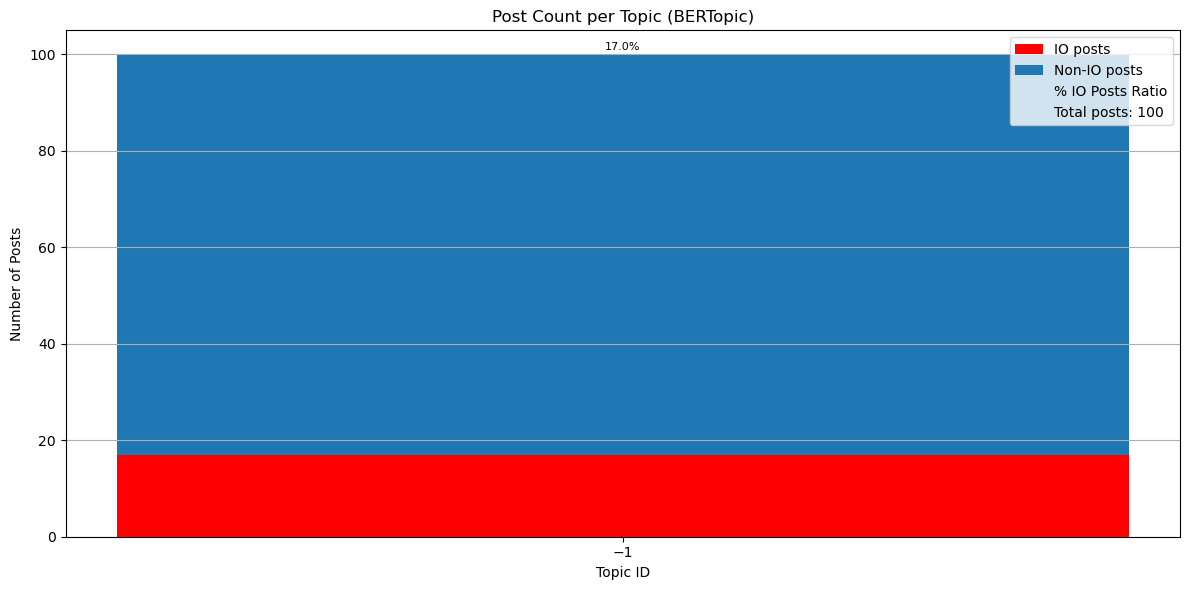

In [ ]:
topic_col_name = "BERTopic_topic"
BERT_topic_stats = make_topic_stats(df, topic_col_name)
plot_topic_stats(BERT_topic_stats, topic_col_name, "BERTopic", output_folder_path)

author_io_tag,BERTopic_topic,control_accounts,io_accounts,total_accounts,io_percent
0,-1,77,7,84,8.333333


Plot saved to ../results/Labeled_Datasets/Ecuador/Ecuador_part_7/2025_12_16/BERTopic_topic_accounts.png


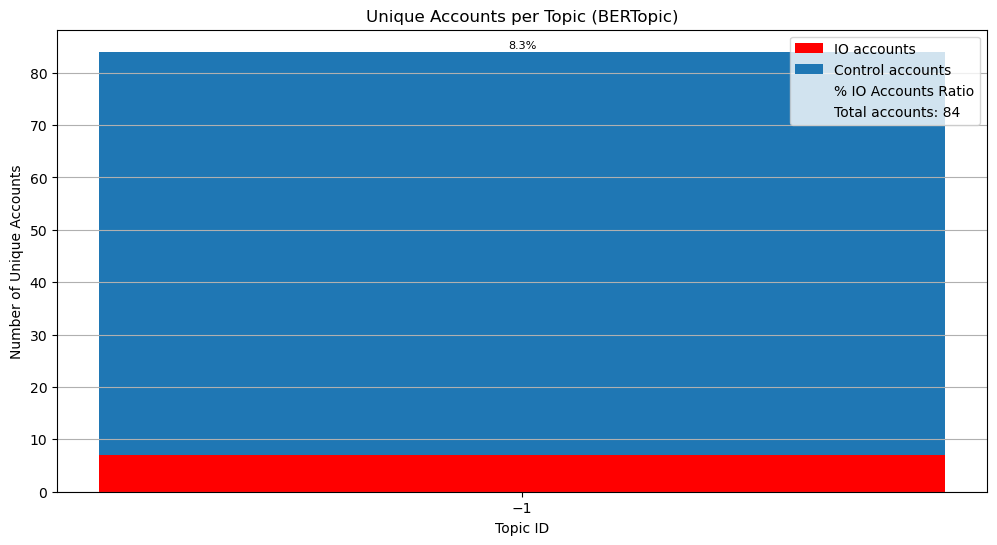

In [ ]:
topic_col_name = "BERTopic_topic"

topic_account_stats = make_topic_account_stats(df, topic_col_name)
display(topic_account_stats)
plot_topic_account_stats(topic_account_stats, topic_col_name, "BERTopic", output_folder_path)

In [ ]:
try:
    fig = BERTopic_model.visualize_topics(custom_labels=True)
    display(fig)   # show it
except Exception as e:
    print("Not enough topics for visualization")
    print("Error:", e)

Not enough topics for visualization
Error: arrays used as indices must be of integer (or boolean) type


## K-Means

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def auto_kmeans_topics(embeddings, k_min=30, k_max=200, step = 4):
    best_k = None
    best_score = -1
    best_labels = None

    for k in range(k_min, k_max + 1, step):
        print(f"Trying k={k}")
        km = KMeans(n_clusters=k, random_state=42, n_init="auto")
        labels = km.fit_predict(embeddings)
        score = silhouette_score(embeddings, labels)

        if score > best_score:
            best_score = score
            best_k = k
            best_labels = labels

    return best_labels, best_k

In [ ]:
# Add to df
labels, best_k = auto_kmeans_topics(embeddings)
df["K_Means_topic"] = labels
print(f"\nBest k: {best_k}")
df.head()

Trying k=4
Trying k=6
Trying k=8
Trying k=10
Trying k=12
Trying k=14
Trying k=16
Trying k=18
Trying k=20
Trying k=22
Trying k=24
Trying k=26
Trying k=28
Trying k=30
Trying k=32
Trying k=34
Trying k=36
Trying k=38
Trying k=40
Best k: 4


,postid,post_text,application_name,post_language,in_reply_to_postid,in_reply_to_accountid,post_time,accountid,account_profile_description,follower_count,...,hashtags,urls,account_mentions,is_control,clean_post_text,clean_text_no_enteties,translated_post,BERTopic_topic,BERTopic_prob,K_Means_topic
333553,de173a9bed7c1cb05ca42f10a7a241a63e468287a4,#ChinaMobile Joins OpenDaylight. Read more: https://d286d62682cba9585c528a2f0f8167b01293672197 $CHL,e7776ff5f5143c092ff4dfebd21db69871893319e1,eng_Latn,None,None,2016-09-27 17:04:19,951e8cccea58fbcb524d716975805096c48311ed1e,Track all of the latest Telecom News with Owler. View all companies in the Telecommunications Equipment Sector: https://611dff062468bb365b720b7cd6d9115b296df9de50,355,...,[ChinaMobile],[https://d286d62682cba9585c528a2f0f8167b01293672197],[],True,hashtag_chinamobile joins opendaylight. read more: url_d286d62682cba9585c528a2f0f8167b01293672197 $chl,chinamobile joins opendaylight. read more: <URL> $chl,Chinamobile is joining Opendaylight. read more: <URL> $chl,-1,0.0,1
309427,1ee636efe4c2c96c27a6b16e635172c0e9b621bc63,Todos pueden decir que te quieren pero lo demuestra quien se queda y hace que luches por ti.,62010408238d4a0f958ec97eec3db0a4f69bcd0d11,spa_Latn,None,None,2016-08-02 19:54:32,ad6e96920a829d286ac37c3cff0cc07d58092d22e5,None,422,...,[],[],[],True,todos pueden decir que te quieren pero lo demuestra quien se queda hace que luches por ti.,todos pueden decir que te quieren pero lo demuestra quien se queda y hace que luches por ti.,"Everyone can say they love you, but whoever stays makes you fight for you.",-1,0.0,2
300199,7f0a196e25876145353480de6b2d23830c3aa5ece1,Un #muerto y #decenas de heridos palestinos deja ataque de Israel\nhttps://daaa2bb6025204194cde9ffb0e09e5a68f60b1660f\n#FelizMiércoles #13jul #MiércolesDeGanarSeguidores,15592fcc82d5064a8f4a3b89774e6cd0bbd2118aa0,spa_Latn,None,None,2016-07-14 01:38:18,a7dbf1afeffc247dc610982f30ba02d30a5fd1bf9b,Comunicador Alternativo en la batalla creativa,976,...,"[muerto, decenas, FelizMiércoles, 13jul, MiércolesDeGanarSeguidores]",[https://daaa2bb6025204194cde9ffb0e09e5a68f60b1660f],[],True,un hashtag_muerto hashtag_decenas de heridos palestinos deja ataque de israel url_daaa2bb6025204194cde9ffb0e09e5a68f60b1660f hashtag_felizmiércoles hashtag_13jul hashtag_miércolesdeganarseguidores,un muerto y decenas de heridos palestinos deja ataque de israel <URL> felizmiércoles 13jul miércolesdeganarseguidores,One dead and dozens wounded Palestinians leaves Israeli attack Happy Wednesday 13 JulyWednesday,-1,0.0,3
312447,c92305e8f77aa9980e73924e63ec351c038b77e267,Nas Album Done is the best song on Major Key for sure,15592fcc82d5064a8f4a3b89774e6cd0bbd2118aa0,eng_Latn,None,None,2016-08-08 22:36:26,e7f50df757d89d8e45a3ce157d798b75cc54ad6056,Josepha ✌🏾💙 Sais tu seulement à quel point tu n'sais pas ?,1081,...,[],[],[08254de8ae37737c3fe890a63e329b9d4a0c2e13e8],True,nas album done best song major key sure,nas album done is the best song on major key for sure,Our album made is the best song on Key Major for sure,-1,0.0,1
339489,c619a80041b23c43971fa90ed54a4960da4b18b773,Herramientas para encontrar palabras clave SEO https://67d753b2963953bf8786bdf64e83abfc5e150955f2 vía @1fd83f44cbcfb91216db08883b646a4150d320df58,62010408238d4a0f958ec97eec3db0a4f69bcd0d11,spa_Latn,None,None,2016-10-10 19:12:42,62545b95bd79568e2d89cb4f2eebf1d33e11439b1c,Reparacion de Pc Actualizacion Instalacion de Software y Hardware Servicio Tecnico Garantizado Tlfs: 0212-4435849 / 0426-6178258,681,...,[],[https://67d753b2963953bf8786bdf64e83abfc5e150955f2],[1fd83f44cbcfb91216db08883b646a4150d320df58],True,herramientas para encontrar palabras clave seo url_67d753b2963953bf8786bdf64e83abfc5e150955f2 vía mention_1fd83f44cbcfb91216db08883b646a4150d320df58,herramientas para encontrar palabras clave seo <URL> vía <USER>,tools to find keywords seo <URL> via <USER>,-1,0.0,3


plot is saved to ../results/Labeled_Datasets/Ecuador/Ecuador_part_7/2025_12_16/K-Means_topic_clustering.png


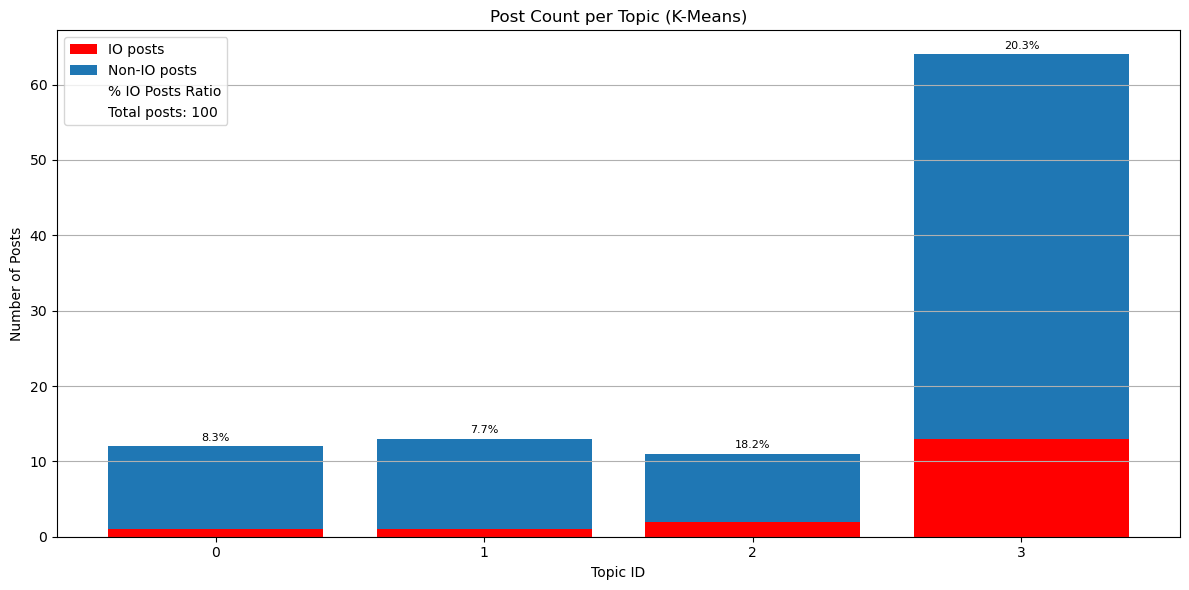

In [ ]:
topic_col_name = "K_Means_topic"
topic_stats = make_topic_stats(df, topic_col_name)
plot_topic_stats(topic_stats, topic_col_name, "K-Means", output_folder_path)

author_io_tag,K_Means_topic,control_accounts,io_accounts,total_accounts,io_percent
0,0,9,1,10,10.000000
1,1,12,1,13,7.692308
2,2,9,2,11,18.181818
3,3,48,6,54,11.111111


Plot saved to ../results/Labeled_Datasets/Ecuador/Ecuador_part_7/2025_12_16/K_Means_topic_accounts.png


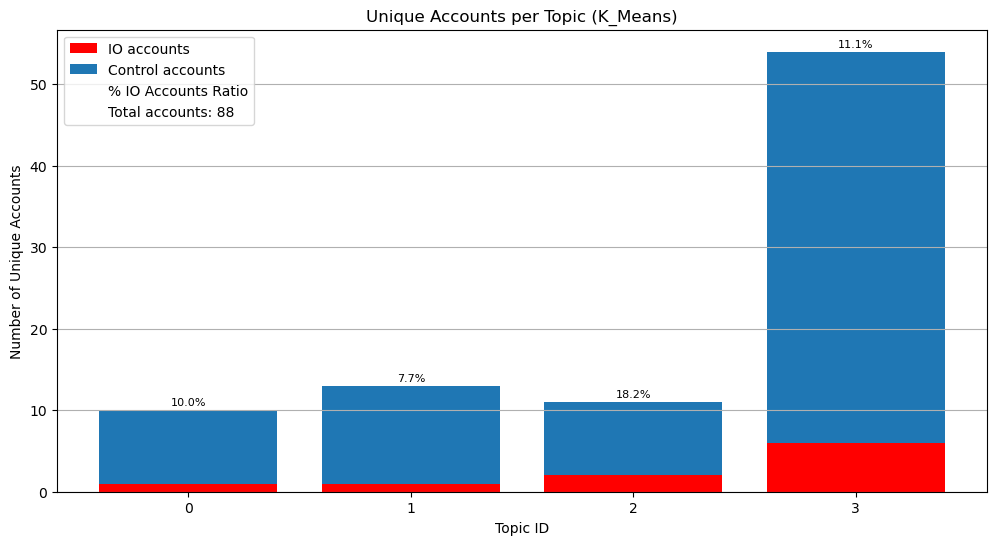

In [ ]:
topic_col_name = "K_Means_topic"

topic_account_stats = make_topic_account_stats(df, topic_col_name)
display(topic_account_stats)
plot_topic_account_stats(topic_account_stats, topic_col_name, "K_Means", output_folder_path)

# Named Entity Recognition (NER)

In [ ]:
from transformers import AutoTokenizer, AutoModelForTokenClassification, pipeline

# Load model ONCE
tokenizer = AutoTokenizer.from_pretrained("TweebankNLP/bertweet-tb2_wnut17-ner")
ner_model = AutoModelForTokenClassification.from_pretrained("TweebankNLP/bertweet-tb2_wnut17-ner")

ner_pipeline = pipeline(
    "token-classification",
    model=ner_model,
    tokenizer=tokenizer,
    aggregation_strategy="simple"
)


def extract_ner_entities(posts_lst: list):
    """
    Runs NER in batches on a list of text posts.

    Args:
          posts_lst (list): List of strings (cleaned posts).
    Returns
    -------
    all_entities (list[list[str]]): For each post: a list of extracted entity words.
    """

    ner_outputs = ner_pipeline(posts_lst)
    all_entities = []
    for post_output in ner_outputs:
        words = [ent["word"] for ent in post_output]
        all_entities.append(words)

    return all_entities

Device set to use cuda:0


In [ ]:
# Apply ONCE, no pandas apply, in order to utilize batches.
df["ner_entities"] = extract_ner_entities(df["translated_post"].to_list())

In [ ]:
# display post with ner entities
df.loc[df["ner_entities"].astype(bool), ["post_text", "translated_post", "ner_entities"]].head()

,clean_post_text,ner_entities
300199,un hashtag_muerto hashtag_decenas de heridos palestinos deja ataque de israel url_daaa2bb6025204194cde9ffb0e09e5a68f60b1660f hashtag_felizmiércoles hashtag_13jul hashtag_miércolesdeganarseguidores,"[palestinos, israel, ér@@, ér@@]"
312447,nas album done best song major key sure,[nas]
310822,nina es la nueva perrita adoptada por el prefecto mention_516b0c1e968fe2c596440e5f94a61374a5bf26609b . ella es otra sobreviviente del terremoto emoji_dog_face emoji_paw_prints url_t…,[nina]
338695,el gracioso gesto que se vio en la ecografía del bebé de ximena capristo | url_3535e9efb79626672e2b8574d0d2560f6a1a318dab hashtag_nohacefakiuanimal hashtag_mepaquetiraresultado,[ximena]
306188,extintores oferta hashtag_vzla hashtag_venezuela hashtag_buenmartes hashtag_felizmartes hashtag_26jul url_7246a064b73c473a766eee3f2f3229654d0ff8e55d,"[ven@@, buenmartes, felizmartes]"


# Clean Entities

In [ ]:
def clean_entity_columns(df, entity_cols_lst):
    """Normalize entity columns to match TfidfVectorizer behavior.

    Converts each entity to a stripped, lowercase string for all columns
    listed in ``entity_cols_lst``.
    The function modifies ``df``.

    Args:
        df: Input DataFrame.
        entity_cols_lst: Columns containing lists of entities.

    Returns:
        None.
    """
    for col in entity_cols_lst:
        df[col] = df[col].apply(lambda lst: [str(e).strip().lower().replace(" ", "_") for e in lst])

In [ ]:
entity_cols_lst = ["hashtags", "account_mentions", "urls", "ner_entities"]
clean_entity_columns(df, entity_cols_lst)

# Entities Statistics

In [ ]:
def entity_topic_counts(
    df: pd.DataFrame,
    entity_col: str,
    topic_col: str,
) -> pd.DataFrame:
    """Return entity-topic count matrix.

    Args:
        df: Input DataFrame.
        entity_col: Column with entity IDs.
        topic_col: Column with topic labels.

    Returns:
        DataFrame with entities as index, topics as columns, counts as values.
    """
    return pd.crosstab(
        index=df[entity_col],
        columns=df[topic_col],
    )

In [ ]:
def plot_entity_topic_distribution(
    entity,
    entity_topic_counts,
    clustering_model: str = "",
    output_folder_path=None,
):
    """Plot how many times a given entity appears in each topic.

    Args:
        entity: Entity ID that exists in entity_topic_counts.index.
        entity_topic_counts: DataFrame from pd.crosstab (index=entity, columns=topic, values=counts).
        clustering_model: Optional label to annotate the plot.
        output_folder_path: If given (Path-like), saves PNG to this folder.
    """
    # Extract row for chosen entity (entity is in the index)
    counts = entity_topic_counts.loc[entity]  # Series: topic_id -> count

    # Topic columns
    topic_cols = list(entity_topic_counts.columns)

    # Ensure consistent order on x-axis (only if sortable)
    topic_cols = sorted(topic_cols)
    counts = counts.loc[topic_cols]

    # --- Plot ---
    plt.figure(figsize=(12, 5))
    plt.bar(topic_cols, counts.values)

    plt.title(f"Topic Distribution for Entity: '{entity}'")
    plt.xlabel("Topic ID")
    plt.ylabel("Count of occurrences")
    plt.xticks(topic_cols)
    plt.grid(axis="y")

    # Metadata note (top-right)
    plt.text(
        0.98, 0.92,
        f"clustering model: {clustering_model}",
        ha="right",
        va="top",
        transform=plt.gca().transAxes
    )

    plt.tight_layout()

    # Save if path provided
    if output_folder_path is not None:
        plot_path = output_folder_path / f"{entity}_topic_distribution.png"
        plt.savefig(plot_path, dpi=300)
        print(f"Saved figure to: {plot_path}")

    plt.show()
    plt.close()

,ner_entities,total_count,io_percent,-1
19,ec@@,3,33.333333,3.0
15,cher@@,3,0.000000,3.0
40,madrid,2,100.000000,2.0
36,la,2,0.000000,2.0
67,ven@@,2,0.000000,2.0


Saved figure to: ../results/Labeled_Datasets/Ecuador/Ecuador_part_7/2025_12_16/ec@@_topic_distribution.png


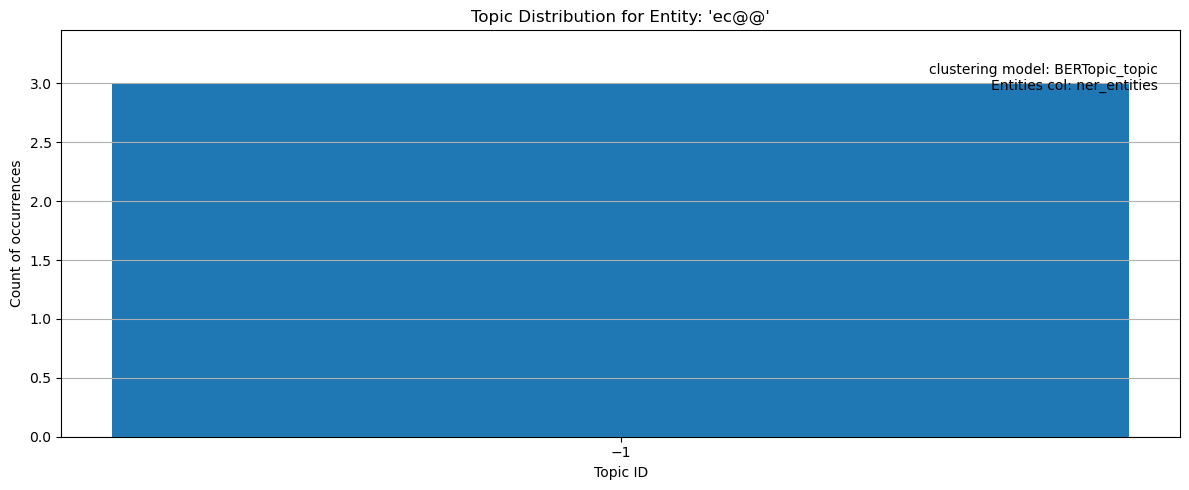

In [ ]:
entity_col_name = "ner_entities"
topic_col = "BERTopic_topic"

entity_topic_counts_df = entity_topic_counts(df, entity_col_name, topic_col)
display(entity_topic_counts_df.head())

entity = entity_topic_matrix[entity_col_name].iloc[0]   # first entity
plot_entity_topic_distribution(entity=entity, entity_topic_counts=entity_topic_counts_df, entity_col=entity_col_name, clustering_model = topic_col, output_folder_path=output_folder_path)

# Save to parquet

In [ ]:
# print dataset statistics
for col in df.columns:
    sample_val = df[col].dropna().iloc[0] if df[col].notna().any() else None
    print(f"{col:<30} | {type(sample_val).__name__}")

postid                         | str
post_text                      | str
application_name               | str
post_language                  | str
in_reply_to_postid             | str
in_reply_to_accountid          | str
post_time                      | Timestamp
accountid                      | str
account_profile_description    | str
follower_count                 | int64
following_count                | int64
account_creation_date          | date
is_repost                      | bool
reposted_accountid             | str
reposted_postid                | str
hashtags                       | list
urls                           | list
account_mentions               | list
is_control                     | bool
clean_post_text                | str
clean_text_no_enteties         | str
translated_post                | str
BERTopic_topic                 | int64
BERTopic_prob                  | float64
K_Means_topic                  | int32
ner_entities                   | list


In [ ]:
df_output_path = output_folder_path / f"Topic_Ner_{file_name}"

df.to_parquet(df_output_path, index=False, compression="gzip")
print("df is saved to:", df_output_path)

df is saved to: ../results/Labeled_Datasets/Ecuador/Ecuador_part_7/2025_12_16/Topic_Ner_Ecuador_part_7.gzip.parquet
